<img src="../assets/reference_images/opencv_logo.png" alt="drawing" style="width:200px;"/> 

# Agenda
1. Read and Show image **(opencv)**
2. Resize , Cropping and Rotating  



## import Resources and Library

In [1]:
import cv2 as cv
import matplotlib.pyplot as plt

def show(img, title=None):
    """Display a BGR/grayscale OpenCV image inline with matplotlib (safe for unattended execution)."""
    if img is None:
        print(f"[{title}] no image to display")
        return
    display_img = cv.cvtColor(img, cv.COLOR_BGR2RGB) if img.ndim == 3 else img
    cmap = None if img.ndim == 3 else 'gray'
    plt.figure()
    plt.imshow(display_img, cmap=cmap)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

path = './images/'

In [2]:
cv.__version__

'5.0.0'

### Read an image from file ([imread(path ,Colorflage)](https://docs.opencv.org/4.x/d4/da8/group__imgcodecs.html#ga288b8b3da0892bd651fce07b3bbd3a56))
- **path :**  location of image in files (For example : image\file\NameOfImage )
- **Colorflage :** to read BGR image value **(1)** and Gray image value **(0)**

<img src="../assets/reference_images/bgr_colorflag_example.png" alt="drawing" style="width:200px;"/> 

In [3]:
path

'./images/'

In [4]:
img = cv.imread(path+'dog.jpg') # default

In [5]:
print(type(img))

<class 'numpy.ndarray'>


In [6]:
img

array([[[ 89,  89,  89],
        [ 88,  88,  88],
        [ 88,  88,  88],
        ...,
        [ 61,  61,  61],
        [ 61,  61,  61],
        [ 60,  60,  60]],

       [[ 89,  89,  89],
        [ 89,  89,  89],
        [ 88,  88,  88],
        ...,
        [ 61,  61,  61],
        [ 61,  61,  61],
        [ 60,  60,  60]],

       [[ 90,  90,  90],
        [ 89,  89,  89],
        [ 89,  89,  89],
        ...,
        [ 61,  61,  61],
        [ 61,  61,  61],
        [ 61,  61,  61]],

       ...,

       [[144, 144, 144],
        [144, 144, 144],
        [145, 145, 145],
        ...,
        [103, 103, 103],
        [103, 103, 103],
        [102, 102, 102]],

       [[144, 144, 144],
        [144, 144, 144],
        [147, 147, 147],
        ...,
        [103, 103, 103],
        [103, 103, 103],
        [102, 102, 102]],

       [[144, 144, 144],
        [145, 145, 145],
        [149, 149, 149],
        ...,
        [103, 103, 103],
        [103, 103, 103],
        [102, 102, 102]]

In [7]:
assert img is not None , "Cant read image"

In [8]:
img.shape
# (Height , Width , numberofchannels)

(300, 332, 3)

### Display an image in an OpenCV window ([imshow(title ,img)](https://docs.opencv.org/4.x/d7/dfc/group__highgui.html#ga453d42fe4cb60e5723281a89973ee563))
- Arguments:
    - title of window
    - image object

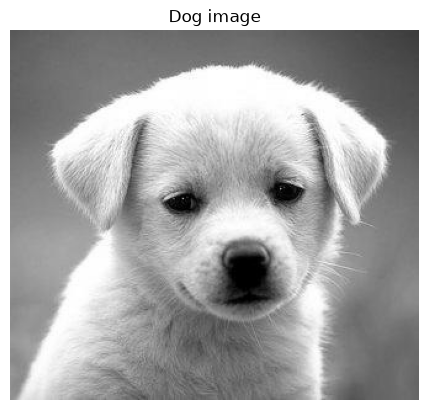

In [9]:
show(img, "Dog image")

## Resize image

Tasks:
- Preserve Aspect Ratio (height to width ratio of image is preserved)
    - Downscale (Decrease the size of the image)
    - Upscale (Increase the size of the image)
- Do not preserve Aspect Ratio
    - Resize only the width (Increase or decrease the width of the image keeping height unchanged)
    - Resize only the height (Increase or decrease the height of the image keeping width unchanged)
    - Resize to specific width and height

### Resize Function(resize(src, dsize[, dst[, fx[, fy[, interpolation]]]]))
- src: It is the required input image, it could be a string with the path of the input image 
- dsize: It is the desired size of the output image, it can be a new height and width.
- fx: Scale factor along the horizontal axis.
- fy: Scale factor along the vertical axis.
- interpolation: It gives us the option of different methods of resizing the image.

### Down Scale (<=100)

In [10]:
# to down scale less than or equal 100
Scale_percent = 60
# height = percent * height /100 and width = percent * width / 100
h,w , _ = img.shape
h = int(Scale_percent *h / 100)
w = int(Scale_percent * w / 100 )
dim = (h,w)

down_img = cv.resize(img, dim , interpolation = cv.INTER_AREA)

In [11]:
print(down_img.shape)
print(img.shape)

(199, 180, 3)
(300, 332, 3)


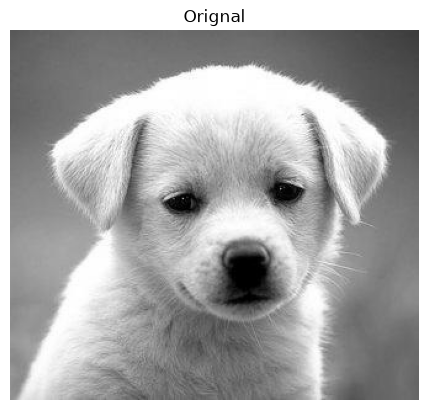

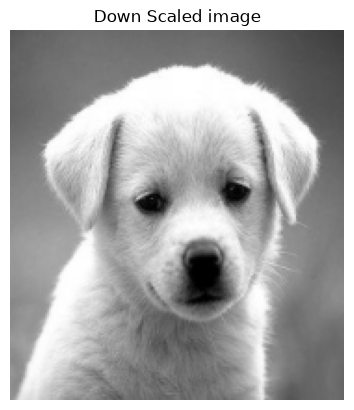

In [12]:
show(img, "Orignal")
show(down_img, "Down Scaled image")

### Up Scale (< 100)

In [13]:
# to UP scale less than or equal 100
Scale_percent = 200

# height = percent * height /100 and width = percent * width / 100

h,w , _ = img.shape
h = int(Scale_percent *h / 100)
w = int(Scale_percent * w / 100 )
dim = (h,w)

UP_img = cv.resize(img, dim , interpolation = cv.INTER_AREA)

In [14]:
print(UP_img.shape)
print(img.shape)

(664, 600, 3)
(300, 332, 3)


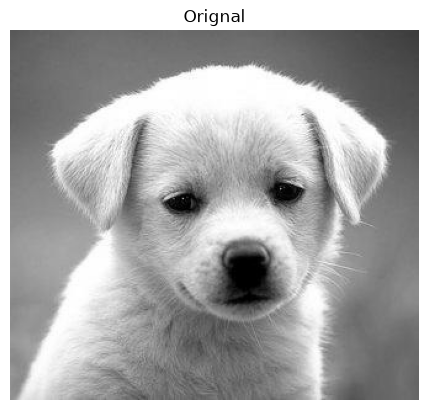

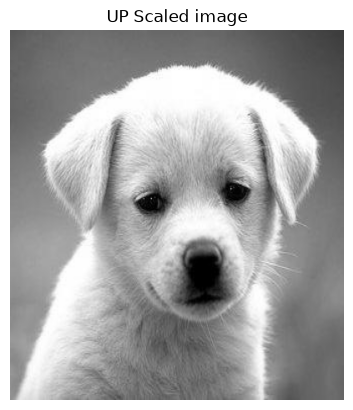

In [15]:
show(img, "Orignal")
show(UP_img, "UP Scaled image")

### Resize only Width

In [16]:
h,w , _ = img.shape
h = h
w = 100
dim = (h,w)

Width_img = cv.resize(img, dim , interpolation = cv.INTER_AREA)

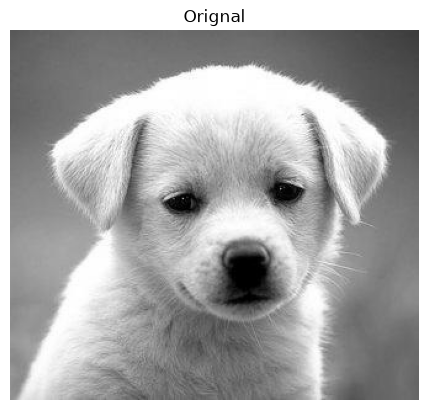

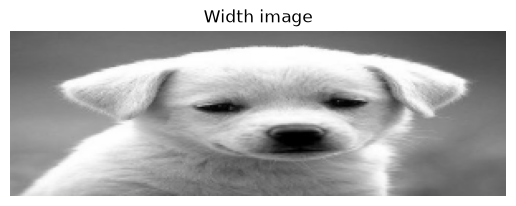

In [17]:
show(img, "Orignal")
show(Width_img, "Width image")

### Resize only Height

In [18]:
h,w , _ = img.shape
h = 200
w = w
dim = (h,w)

Height_img = cv.resize(img, dim , interpolation = cv.INTER_AREA)

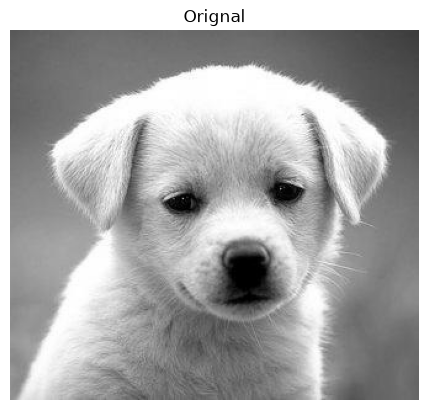

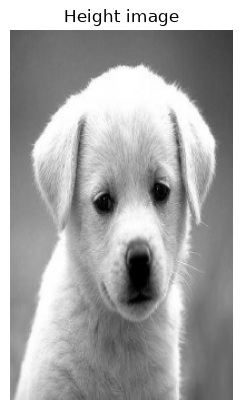

In [19]:
show(img, "Orignal")
show(Height_img, "Height image")

### Resize with Height and Width

In [20]:
h,w , _ = img.shape
h = 200
w = 200
dim = (h,w)

HW_img = cv.resize(img, dim , interpolation = cv.INTER_AREA)

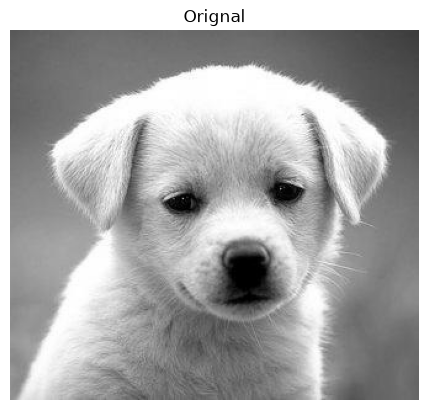

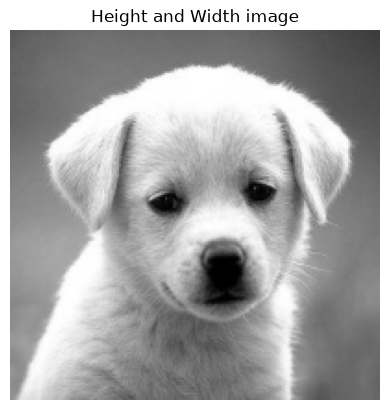

In [21]:
show(img, "Orignal")
show(HW_img, "Height and Width image")

### Scale with fx and fy

In [22]:
# Scaling Up the image 1.2 times by specifying both scaling factors
scale_up_x = 1.2
scale_up_y = 1.2
# Scaling Down the image 0.6 times specifying a single scale factor.
scale_down = 0.6
 
scaled_f_down = cv.resize(img, None, fx= scale_down, fy= scale_down, interpolation= cv.INTER_LINEAR)
scaled_f_up = cv.resize(img, None, fx= scale_up_x, fy= scale_up_y, interpolation= cv.INTER_LINEAR)

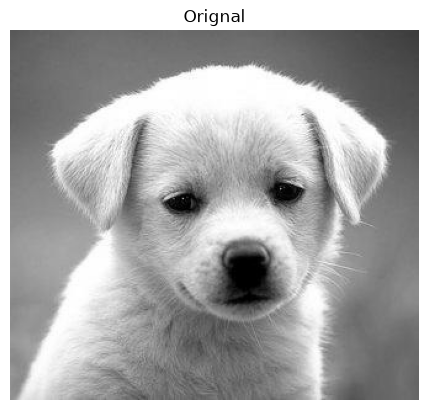

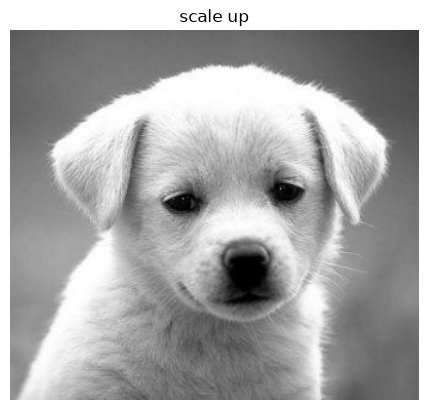

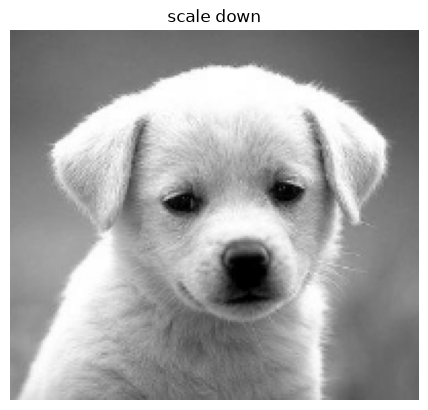

In [23]:
show(img, "Orignal")
show(scaled_f_up, "scale up")
show(scaled_f_down, "scale down")

## Exercises

- Resizing With Different Interpolation Methods

# Cropping

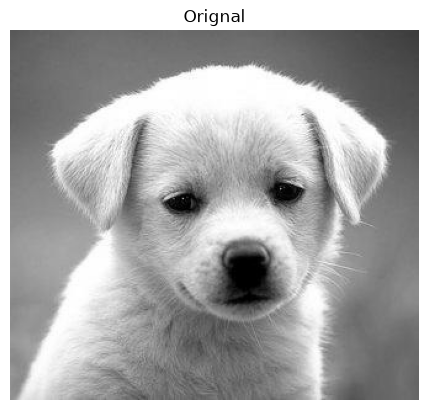

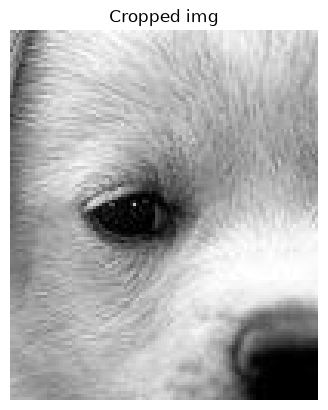

In [24]:
Cropped_img = img [80:200 , 100:200]
show(img, "Orignal")
show(Cropped_img, "Cropped img")

## Exercises
1- Pathing image to blocks

<img src="../assets/reference_images/crop_example.jpg" alt="drawing" style="width:400px;"/>

## Rotating

You can rotate an image by a certain angle $\theta$ by defining a transformation matrix M. This matrix is usually of the form:

$$M = \begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix}$$

OpenCV provides the ability to define the center of rotation for the image and a scale factor to resize the image as well. In that case, the transformation matrix gets modified.

$$M = \begin{bmatrix} \alpha & \beta & (1-\alpha) \cdot c_x - \beta \cdot c_y \\ -\beta & \alpha & \beta \cdot c_x + (1-\alpha) \cdot c_y \end{bmatrix}$$

In the above matrix:

$$\alpha = scale \cdot \cos\theta \qquad \beta = scale \cdot \sin\theta$$

where ${c_x}$ & ${c_y}$ are the coordinates along which the image is rotated.

OpenCV provides **the getRotationMatrix2D()** function to create the above transformation matrix.

## getRotationMatrix2D(center, angle, scale)


The getRotationMatrix2D() function takes the following arguments:

- center: the center of rotation for the input image
- angle: the angle of rotation in degrees
- scale: an isotropic scale factor which scales the image up or down according to the value provided

If the angle is positive, the image gets rotated in the counter-clockwise direction. If you want to rotate the image clockwise by the same amount, then the angle needs to be negative.

In [25]:
height, width , _= img.shape
center = (width/2, height/2)  

In [26]:
rotate_matrix = cv.getRotationMatrix2D(center=center, angle=45, scale=1)

In [27]:
rotate_matrix

array([[  0.70710678,   0.70710678, -57.44574285],
       [ -0.70710678,   0.70710678, 161.3137085 ]])

## warpAffine(src, M, dsize[, dst[, flags[, borderMode[, borderValue]]]])

The following are the arguments of the function:

- src: the source mage
- M: the transformation matrix
- dsize: size of the output image
- dst: the output image
- flags: combination of interpolation methods such as INTER_LINEAR or INTER_NEAREST
- borderMode: the pixel extrapolation method
- borderValue: the value to be used in case of a constant border, has a default value of 0

In [28]:
# Rotate the image using cv2.warpAffine
rotated_image = cv.warpAffine(src=img, M=rotate_matrix, dsize=(width, height))
print(img.shape)
print(rotated_image.shape)

(300, 332, 3)
(300, 332, 3)


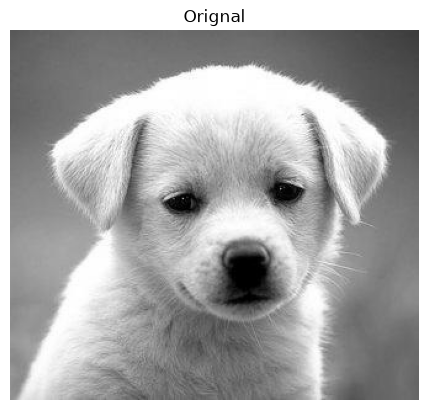

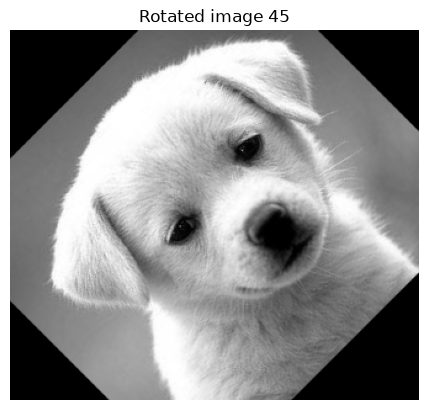

In [29]:
show(img, "Orignal")
show(rotated_image, "Rotated image 45")

In [30]:
rotate_matrix_90 = cv.getRotationMatrix2D(center=center, angle = 90, scale=1)
rotate_matrix_180 = cv.getRotationMatrix2D(center=center, angle = 180, scale=1)

In [31]:
rotated_image_90 = cv.warpAffine(src=img, M=rotate_matrix_90, dsize=(width, height))
rotated_image_180 = cv.warpAffine(src=img, M=rotate_matrix_180, dsize=(width, height))

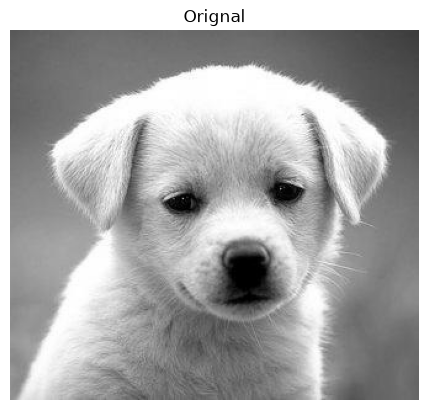

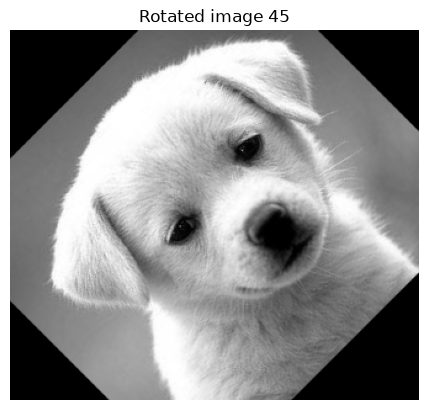

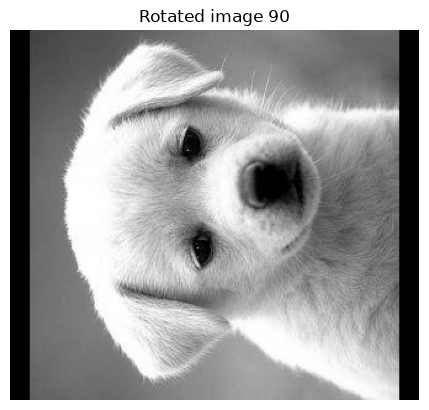

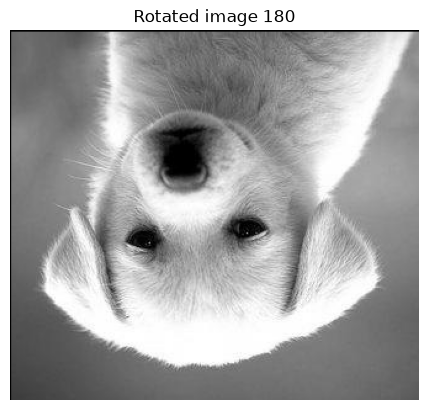

In [32]:
show(img, "Orignal")
show(rotated_image, "Rotated image 45")
show(rotated_image_90, "Rotated image 90")
show(rotated_image_180, "Rotated image 180")

Read :
ٌٌُ
1. https://pyimagesearch.com/2021/02/03/opencv-image-translation/
2. https://pyimagesearch.com/2021/01/20/opencv-rotate-image/